## Тема занятия: пакетная нормализация в обучении нейронных сетей (Батч-нормализация)

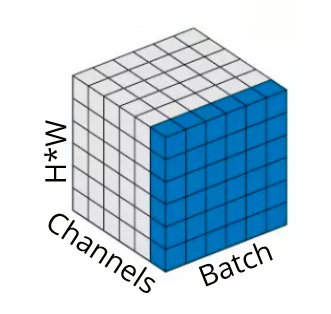

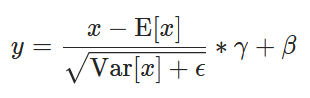

Внутренний ковариационный сдвиг — серьёзная проблема, с которой сталкиваются при обучении моделей глубокого обучения. Пакетная нормализация была введена для решения этой проблемы.

Пакетная нормализация была введена для смягчения проблемы внутреннего ковариационного сдвига в нейронных сетях Сергеем Иоффе и Кристианом Сегеди в 2015 году. Процесс нормализации включает вычисление среднего значения и дисперсии каждого признака в мини-пакете, а затем масштабирование и сдвиг признаков с использованием этой статистики. Это гарантирует, что входные данные для каждого слоя остаются примерно в том же распределении, независимо от изменений в распределении выходных данных более ранних слоёв. Следовательно, пакетная нормализация помогает стабилизировать процесс обучения, обеспечивая более высокую скорость обучения и более быструю сходимость.

**Необходимость в батч-нормализации**
Пакетная нормализация — это расширение концепции нормализации от входного слоя до активаций каждого скрытого слоя по всей нейронной сети. 

В традиционных нейронных сетях по мере распространения входных данных по сети распределение входов каждого слоя меняется. Это явление, известное как внутренний ковариационный сдвиг может замедлить процесс обучения (или даже препятствовать сходимости сети во время обучения). Пакетная нормализация направлена на смягчение этой проблемы путём нормализации входных данных каждого слоя. 

Входными данными для каждого скрытого слоя являются выходные данные предыдущего слоя. Если эти выходные данные нормализованы, это гарантирует, что сеть постоянно получает входные данные с одинаковым распределением, независимо от этапа обучения. Такая стабильность распределения входных данных обеспечивает более плавное и эффективное обучение.

При применении пакетной нормализации к скрытым слоям сети градиенты, распространяющиеся во время обратного распространения ошибки, с меньшей вероятностью будут исчезать или увеличиваться, что приводит к более стабильной динамике обучения. В конечном итоге это способствует более быстрой сходимости и повышению производительности нейронной сети при выполнении заданной задачи.

Будем использовать код из предыдущего занятия.<br>
Изменим архитектуру : добавим **батч-нормализацию** (torch.nn.BatchNorm2d)

In [16]:
import torch
import random
import numpy as np

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed(0)
torch.backends.cudnn.deterministic = True

In [17]:
import torchvision.datasets

In [18]:
MNIST_train = torchvision.datasets.MNIST('./', download=False, train=True)
MNIST_test = torchvision.datasets.MNIST('./', download=False, train=False)


In [19]:
X_train = MNIST_train.data
y_train = MNIST_train.targets
X_test = MNIST_test.data
y_test = MNIST_test.targets

In [20]:
len(y_train), len(y_test)

(60000, 10000)

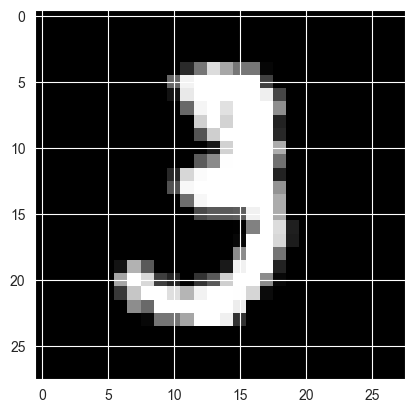

tensor(3)


In [21]:
import matplotlib.pyplot as plt
plt.imshow(X_train[10, :, :])
plt.gray()
plt.show()
print(y_train[10])

In [22]:
X_train = X_train.unsqueeze(1).float()
X_test = X_test.unsqueeze(1).float()

In [23]:
X_train.shape

torch.Size([60000, 1, 28, 28])

In [24]:
class LeNet5(torch.nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()

        self.conv1 = torch.nn.Conv2d(
            in_channels=1, out_channels=6, kernel_size=5, padding=2)
        self.act1  = torch.nn.Tanh()
        self.pool1 = torch.nn.AvgPool2d(kernel_size=2, stride=2)

        self.conv2 = torch.nn.Conv2d(
            in_channels=6, out_channels=16, kernel_size=5, padding=0)
        self.act2  = torch.nn.Tanh()
        self.pool2 = torch.nn.AvgPool2d(kernel_size=2, stride=2)

        self.fc1   = torch.nn.Linear(5 * 5 * 16, 120)
        self.act3  = torch.nn.Tanh()

        self.fc2   = torch.nn.Linear(120, 84)
        self.act4  = torch.nn.Tanh()

        self.fc3   = torch.nn.Linear(84, 10)



    def forward(self, x):

        x = self.conv1(x)
        x = self.act1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.act2(x)
        x = self.pool2(x)

        x = x.view(x.size(0), x.size(1) * x.size(2) * x.size(3))

        x = self.fc1(x)
        x = self.act3(x)
        x = self.fc2(x)
        x = self.act4(x)
        x = self.fc3(x)

        return x

lenet5 = LeNet5()

In [25]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
lenet5 = lenet5.to(device)

In [26]:
loss = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(lenet5.parameters(), lr=1.0e-3)

In [27]:
batch_size = 100

test_accuracy_history = []
test_loss_history = []

X_test = X_test.to(device)
y_test = y_test.to(device)

for epoch in range(10):
    order = np.random.permutation(len(X_train))
    for start_index in range(0, len(X_train), batch_size):
        optimizer.zero_grad()

        batch_indexes = order[start_index:start_index+batch_size]

        X_batch = X_train[batch_indexes].to(device)
        y_batch = y_train[batch_indexes].to(device)

        preds = lenet5.forward(X_batch)

        loss_value = loss(preds, y_batch)
        loss_value.backward()

        optimizer.step()

    test_preds = lenet5.forward(X_test)
    test_loss_history.append(loss(test_preds, y_test).data.cpu())

    accuracy = (test_preds.argmax(dim=1) == y_test).float().mean().data.cpu()
    test_accuracy_history.append(accuracy)

    print(accuracy)

tensor(0.9754)
tensor(0.9832)
tensor(0.9858)
tensor(0.9871)
tensor(0.9883)
tensor(0.9886)
tensor(0.9895)
tensor(0.9903)
tensor(0.9885)
tensor(0.9886)


In [28]:
lenet5.forward(X_test)

tensor([[-1.6964, -1.0560, -0.4882,  ..., 12.6452, -0.0918,  2.2306],
        [ 1.2760, -0.1797, 15.0401,  ..., -3.3090,  1.4549, -3.7371],
        [-1.1482, 14.5062, -2.6117,  ...,  1.4974,  0.6122, -1.3853],
        ...,
        [-3.6063, -1.1021, -4.1384,  ...,  1.0993,  2.2419,  3.5134],
        [-1.3777, -3.4534, -4.9913,  ..., -5.9475,  3.4506, -1.5602],
        [ 1.8810, -5.1826,  1.1298,  ..., -6.9122,  0.7860, -3.4902]],
       grad_fn=<AddmmBackward0>)

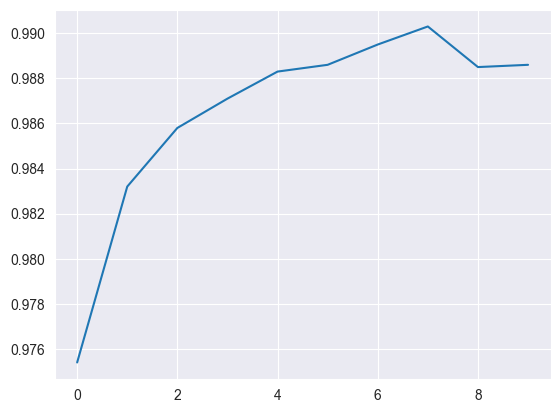

In [29]:
plt.plot(test_accuracy_history);
# plt.plot(test_loss_history);

## Задание 1

Провести исследование влияния гиперпараметров на сходимость икачесвто сети при обучении на MNIST
1. Функции activation = 'tanh', 'relu'
2. Вид пуллинга    pooling = 'avg','max'
3. Свертки  conv_size  = 5, каскад сверток conv_size  = 3
4. Слой batch_normalization
5. Логгировать обучение с помощью TensorBoard.

/Users/bereznevn/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


=== Run: activation=tanh, pooling=avg, bn=True ===
epoch=1/10 accuracy=0.97650 loss=0.07275
epoch=2/10 accuracy=0.98780 loss=0.03993
epoch=3/10 accuracy=0.98490 loss=0.04560
epoch=4/10 accuracy=0.98810 loss=0.03792
epoch=5/10 accuracy=0.98930 loss=0.03701
epoch=6/10 accuracy=0.98760 loss=0.03679
epoch=7/10 accuracy=0.98980 loss=0.03432
epoch=8/10 accuracy=0.98960 loss=0.03493
epoch=9/10 accuracy=0.99090 loss=0.02818
epoch=10/10 accuracy=0.99070 loss=0.02830
=== Run: activation=tanh, pooling=max, bn=True ===
epoch=1/10 accuracy=0.97310 loss=0.08381
epoch=2/10 accuracy=0.97950 loss=0.06329
epoch=3/10 accuracy=0.98140 loss=0.05826
epoch=4/10 accuracy=0.98290 loss=0.05310
epoch=5/10 accuracy=0.98370 loss=0.04873
epoch=6/10 accuracy=0.98460 loss=0.04875
epoch=7/10 accuracy=0.98610 loss=0.04542
epoch=8/10 accuracy=0.98670 loss=0.04405
epoch=9/10 accuracy=0.98410 loss=0.05124
epoch=10/10 accuracy=0.98570 loss=0.04869
=== Run: activation=relu, pooling=avg, bn=True ===
epoch=1/10 accuracy=0.977

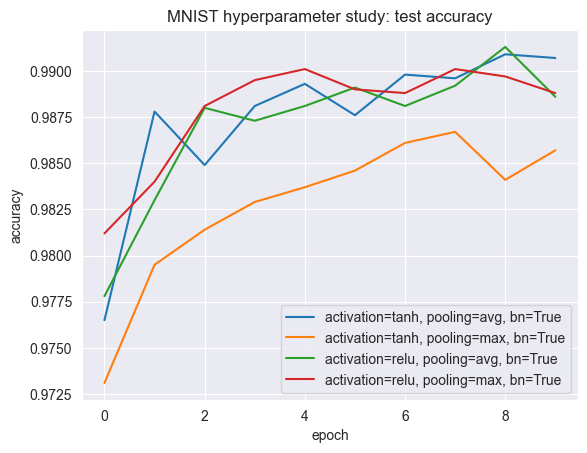

In [30]:
# --- Task 1: Hyperparameter study on MNIST (activation / pooling / BatchNorm) ---

# TensorBoard is optional: if it is not available in the environment, we still train.
try:
    from torch.utils.tensorboard import SummaryWriter
except ImportError:
    SummaryWriter = None

# Hyperparameters from the task description
activation_list = ['tanh', 'relu']
pooling_list = ['avg', 'max']
use_batch_norm = True

# Convolution cascade: conv1 kernel_size=5, conv2 kernel_size=3 (as requested)
conv1_kernel_size = 5
conv2_kernel_size = 3

# Training settings
batch_size = 100
epochs = 10
learning_rate = 1.0e-3


class MNISTConvNet(torch.nn.Module):
    def __init__(
        self,
        activation_name: str,
        pooling_name: str,
        use_batch_norm: bool,
        conv1_kernel: int,
        conv2_kernel: int,
    ):
        super().__init__()

        if activation_name.lower() == 'tanh':
            act_cls = torch.nn.Tanh
        elif activation_name.lower() == 'relu':
            act_cls = torch.nn.ReLU
        else:
            raise ValueError(f"Unsupported activation: {activation_name}")

        if pooling_name.lower() == 'avg':
            pool_cls = torch.nn.AvgPool2d
        elif pooling_name.lower() == 'max':
            pool_cls = torch.nn.MaxPool2d
        else:
            raise ValueError(f"Unsupported pooling: {pooling_name}")

        # Keep spatial size after conv1 (kernel=5 => padding=2)
        conv1_padding = conv1_kernel // 2

        self.conv1 = torch.nn.Conv2d(
            in_channels=1,
            out_channels=6,
            kernel_size=conv1_kernel,
            padding=conv1_padding,
        )
        self.bn1 = torch.nn.BatchNorm2d(6) if use_batch_norm else torch.nn.Identity()
        self.act1 = act_cls()
        self.pool1 = pool_cls(kernel_size=2, stride=2)

        self.conv2 = torch.nn.Conv2d(
            in_channels=6,
            out_channels=16,
            kernel_size=conv2_kernel,
            padding=0,
        )
        self.bn2 = torch.nn.BatchNorm2d(16) if use_batch_norm else torch.nn.Identity()
        self.act2 = act_cls()
        self.pool2 = pool_cls(kernel_size=2, stride=2)

        # Infer flatten dimension for fc1
        with torch.no_grad():
            dummy = torch.zeros(1, 1, 28, 28)
            x = self.conv1(dummy)
            x = self.bn1(x)
            x = self.act1(x)
            x = self.pool1(x)
            x = self.conv2(x)
            x = self.bn2(x)
            x = self.act2(x)
            x = self.pool2(x)
            n_features = x.view(1, -1).shape[1]

        self.fc1 = torch.nn.Linear(n_features, 120)
        self.act3 = act_cls()
        self.fc2 = torch.nn.Linear(120, 84)
        self.act4 = act_cls()
        self.fc3 = torch.nn.Linear(84, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.act1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.act2(x)
        x = self.pool2(x)

        x = x.view(x.size(0), x.size(1) * x.size(2) * x.size(3))

        x = self.fc1(x)
        x = self.act3(x)
        x = self.fc2(x)
        x = self.act4(x)
        x = self.fc3(x)
        return x


def train_one_run(model, log_dir: str):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = torch.nn.CrossEntropyLoss()

    writer = SummaryWriter(log_dir=log_dir) if SummaryWriter is not None else None

    test_accuracy_history = []
    test_loss_history = []

    # Move tensors to device once per run (faster than per-batch .to(device))
    X_train_device = X_train.to(device)
    y_train_device = y_train.to(device)
    X_test_device = X_test.to(device)
    y_test_device = y_test.to(device)

    model.train()
    for epoch in range(epochs):
        order = np.random.permutation(len(X_train_device))

        for start_index in range(0, len(X_train_device), batch_size):
            optimizer.zero_grad()

            batch_indexes = order[start_index : start_index + batch_size]
            X_batch = X_train_device[batch_indexes]
            y_batch = y_train_device[batch_indexes]

            preds = model.forward(X_batch)
            loss_value = criterion(preds, y_batch)
            loss_value.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            test_preds = model.forward(X_test_device)
            test_loss = criterion(test_preds, y_test_device).item()
            accuracy = (test_preds.argmax(dim=1) == y_test_device).float().mean().item()

        test_accuracy_history.append(accuracy)
        test_loss_history.append(test_loss)

        if writer is not None:
            writer.add_scalar('test/accuracy', accuracy, epoch)
            writer.add_scalar('test/loss', test_loss, epoch)

        print(f"epoch={epoch+1}/{epochs} accuracy={accuracy:.5f} loss={test_loss:.5f}")
        model.train()

    if writer is not None:
        writer.close()

    return test_accuracy_history, test_loss_history


run_histories = {}

for activation_name in activation_list:
    for pooling_name in pooling_list:
        run_key = f"activation={activation_name}, pooling={pooling_name}, bn={use_batch_norm}"
        log_dir = f"./runs_mnist_bn/activation={activation_name}_pooling={pooling_name}_bn={use_batch_norm}"

        print(f"=== Run: {run_key} ===")
        model = MNISTConvNet(
            activation_name=activation_name,
            pooling_name=pooling_name,
            use_batch_norm=use_batch_norm,
            conv1_kernel=conv1_kernel_size,
            conv2_kernel=conv2_kernel_size,
        ).to(device)

        acc_hist, loss_hist = train_one_run(model, log_dir=log_dir)
        run_histories[run_key] = {'accuracy': acc_hist, 'loss': loss_hist}


# Plot test accuracy convergence curves
for run_key, hist in run_histories.items():
    plt.plot(hist['accuracy'], label=run_key)

plt.title('MNIST hyperparameter study: test accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.show()


## Задание 2

Обучить вашу нейронную сеть на датасете Cifar10

In [31]:
CIFAR_train = torchvision.datasets.CIFAR10('./', download=True, train=True)
CIFAR_test = torchvision.datasets.CIFAR10('./', download=True, train=False)

100.0%


In [32]:
X_train = torch.FloatTensor(CIFAR_train.data)
y_train = torch.LongTensor(CIFAR_train.targets)
X_test = torch.FloatTensor(CIFAR_test.data)
y_test = torch.LongTensor(CIFAR_test.targets)

In [33]:
CIFAR_train.classes

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [34]:
CIFAR_train.class_to_idx

{'airplane': 0,
 'automobile': 1,
 'bird': 2,
 'cat': 3,
 'deer': 4,
 'dog': 5,
 'frog': 6,
 'horse': 7,
 'ship': 8,
 'truck': 9}

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [2.0..254.0].


tensor(9)


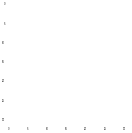

In [35]:
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
figure(figsize = (8,8), dpi =20)
plt.imshow(X_train[1000, :, :])
print(y_train[1000])

In [36]:
# размерность тензора [N C W H]

In [37]:
X_train.shape

torch.Size([50000, 32, 32, 3])